# Stock price direction prediction

## Overview

This notebook addresses the **binary classification** problem of predicting 
whether the next trading day's closing price will be higher than 
today's (`target_direction = 1`) or not (`target_direction = 0`).

The modeling pipeline consists of the following steps:

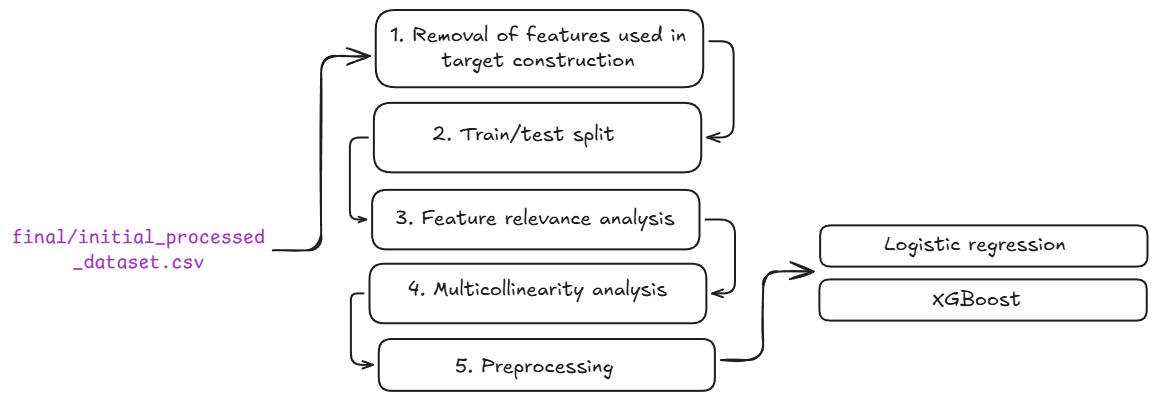

## 1. Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    roc_curve, auc
)
from xgboost import XGBClassifier

company_colors = {"NVDA": "#4DB6AC", "AMD": "#BA68C8", "INTC": "#5C9BD5"}
sns.set_theme(style="ticks", font_scale=1.1)

RANDOM_STATE = 42
TEST_SIZE    = 0.2

META_COLS   = ['date']
TARGET_COL  = 'target_direction'
DROP_COLS   = META_COLS + [
                TARGET_COL, 
                'target_log_volatility_5d',
            ] 

SENTIMENT_COLS = [
    'reddit_sentiment',
    'news_sentiment'
]

ACTIVITY_COLS = [
    'reddit_post_count',
    'reddit_comment_count', 
    'news_count'
]

SOCIAL_NEWS_COLS = SENTIMENT_COLS + ACTIVITY_COLS

df = pd.read_csv('datasets/final/initial_processed_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['company', 'date']).reset_index(drop=True)


print(f'Shape   : {df.shape}')
print(f'Period  : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Companies: {df["company"].unique().tolist()}')

Shape   : (7413, 57)
Period  : 2016-05-31 to 2026-03-27
Companies: ['AMD', 'INTC', 'NVDA']


*Special attention is given to the following **social media and news features**:*
 - `reddit_sentiment`, `news_sentiment` — *sentiment scores derived from BERT inference*
 - `reddit_post_count`, `reddit_comment_count` — *measures of Reddit activity and engagement*
 - `news_count` — *measure of media attention intensity*

## 2. Removal of features used in target construction

`close` is removed because it participates in the construction of prediction target.

`target_direction` is defined as:

$$\text{target\_direction} = \mathbb{1}\left[\text{close}_{t+1} > \text{close}_t\right]$$



In [2]:
cols_to_drop = ['close']

print(f'Dropping {len(cols_to_drop)} columns: {cols_to_drop}')

df = df.drop(columns=cols_to_drop)

print(f'Shape after dropping: {df.shape}')

Dropping 1 columns: ['close']
Shape after dropping: (7413, 56)


## 3. Dataset split

Since the dataset represents a financial time series, a random split 
would introduce data leakage by allowing the model to train on future 
observations and predict past ones. A chronological 80/20 split is 
therefore applied, where the first 80% of trading days form the 
training set and the remaining 20% form the test set.

In [3]:
df = df.sort_values('date').reset_index(drop=True)

split_date = df["date"].quantile(1 - TEST_SIZE)

train_df = df[df["date"] <= split_date].copy()
test_df  = df[df["date"] > split_date].copy()

print(f'Train period : {train_df["date"].min().date()} to {train_df["date"].max().date()}')
print(f'Test period  : {test_df["date"].min().date()} to {test_df["date"].max().date()}')
print(f'Train size   : {len(train_df)} rows ({100*(1-TEST_SIZE):.0f}%)')
print(f'Test size    : {len(test_df)} rows ({100*TEST_SIZE:.0f}%)')

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET_COL]

X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df[TARGET_COL]

print(f'\nX_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'\nTarget distribution (train):')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nTarget distribution (test):')
print(y_test.value_counts(normalize=True).round(3))

Train period : 2016-05-31 to 2024-04-08
Test period  : 2024-04-09 to 2026-03-27
Train size   : 5931 rows (80%)
Test size    : 1482 rows (20%)

X_train shape : (5931, 53)
X_test shape  : (1482, 53)

Target distribution (train):
target_direction
1    0.526
0    0.474
Name: proportion, dtype: float64

Target distribution (test):
target_direction
1    0.503
0    0.497
Name: proportion, dtype: float64


## 4. Feature relevance analysis

*Feature relevance analysis was performed exclusively on the training set to avoid information leakage from the test data.*

Since the target variable is binary and the predictor variables do not satisfy the assumptions required by parametric tests, a non-parametric statistical approach was employed. The Mann–Whitney U test was used to assess whether the distribution of each predictor differs significantly between the two target classes.

In [4]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

*We have all numeric feature except Company. Latter in preprocessing step we will do one-hot encoding of this variable so it can be used in models that requires numeric inputs.*

### 4.1 Mann–Whitney U Test

The Mann–Whitney U test is a non-parametric statistical test used to determine whether two independent samples originate from the same distribution.

For each predictor, the Mann–Whitney U test was used to compare feature values between the two target classes (`target_direction = 0` and `target_direction = 1`).

Alongside the U statistic and p-value, the Rank-Biserial Correlation (RBC) was computed as a measure of effect size, indicating the magnitude of the difference between classes.

The Rank-Biserial Correlation (RBC) was computed as:

$$
r_{rb} = 1 - \frac{2U}{n_1 n_2}
$$

where $U$ denotes the Mann–Whitney U statistic and $n_1$ and $n_2$ represent the sizes of the two groups.

Since the Mann–Whitney U test evaluates each predictor independently, it provides insight into the individual discriminatory power of each feature.

In [5]:
mw_results = []

for feature in numeric_cols:
    # Missing values were handled on a feature-by-feature basis. 
    # For each Mann–Whitney U test, observations with missing values
    #  in the corresponding predictor were excluded from that specific analysis only,
    #  while remaining available for analyses of other predictors.
    group_0 = X_train.loc[y_train == 0, feature].dropna()
    group_1 = X_train.loc[y_train == 1, feature].dropna()

    if len(group_0) == 0 or len(group_1) == 0:
        continue

    u_stat, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative='two-sided'
    )

    n0 = len(group_0)
    n1 = len(group_1)

    rank_biserial = (2 * u_stat) / (n0 * n1) - 1

    mw_results.append({
        'feature': feature,
        'u_statistic': u_stat,
        'p_value': p_value,
        'rank_biserial': rank_biserial,
        'abs_rank_biserial': abs(rank_biserial)
    })

mw_df = (
    pd.DataFrame(mw_results)
    .sort_values('abs_rank_biserial', ascending=False)
    .reset_index(drop=True)
)

mw_df['mw_rank'] = range(1, len(mw_df) + 1)

pd.reset_option('display.float_format')
print(mw_df.to_string(index=False))

             feature  u_statistic  p_value  rank_biserial  abs_rank_biserial  mw_rank
              wma_10    4606605.0 0.000764       0.050536           0.050536        1
                 low    4605833.5 0.000797       0.050360           0.050360        2
                high    4605586.5 0.000808       0.050304           0.050304        3
                open    4604582.0 0.000853       0.050075           0.050075        4
            bb_upper    4603891.5 0.000886       0.049917           0.049917        5
              sma_10    4603576.5 0.000902       0.049845           0.049845        6
              atr_14    4602279.0 0.000967       0.049549           0.049549        7
              sma_20    4595571.5 0.001384       0.048020           0.048020        8
           bb_middle    4595571.5 0.001384       0.048020           0.048020        9
       nasdaq_return    4593418.0 0.001549       0.047529           0.047529       10
         soxx_return    4586332.0 0.002231       0.045

*Although some variables exhibit significant differences between classes (p < 0.05), all effect sizes remain small (|RBC| < 0.06), indicating weak individual discriminatory power.*

**These results suggest that stock price direction cannot be reliably explained by any single predictor in isolation, supporting the use of multivariate machine learning models capable of combining information from multiple indicators.**

## 5. Multicollinearity analysis
Multicollinearity analysis was performed to identify and remove predictors
that carry highly redundant information. This step was primarily motivated
by the inclusion of Logistic Regression in the modeling pipeline, whose
coefficient estimates can become unstable and difficult to interpret when
highly correlated predictors are present.

Although XGBoost is inherently robust to multicollinearity due to its
tree-based structure, the same reduced feature set is applied to both
models. This decision was made to keep the comparison between models
consistent.


### 5.1 Variance Inflation Factor (VIF)
Variance Inflation Factor (VIF) analysis was conducted to identify multicollinearity among predictors. Following commonly adopted guidelines, variables with VIF values exceeding 10 were examined as potential sources of severe multicollinearity.

In [6]:
X_train_vif = X_train[numeric_cols].copy()

X_train_vif = X_train_vif.replace([np.inf, -np.inf], np.nan)
X_train_vif = X_train_vif.fillna(0)

def calculate_vif(X):
    vif_data = []

    for i, col in enumerate(X.columns):
        vif_data.append({
            "feature": col,
            "VIF": variance_inflation_factor(X.values, i)
        })

    return (
        pd.DataFrame(vif_data)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

vif_df = calculate_vif(X_train_vif)


In [7]:
pd.options.display.float_format = '{:.0f}'.format
vif_df.sort_values("VIF", ascending=False)

,feature,VIF
0,sma_20,310593077749689
1,bb_middle,191642537334915
2,bb_upper,7581817554496
3,DGS2,3427396976690
4,bb_lower,939620201830
5,yield_spread,71218920036
6,DGS10,27128974244
7,wma_10,49828
8,sma_10,24999
9,low,3783


Rather than removing all variables above the threshold automatically, predictors involved in deterministic or near-deterministic mathematical relationships were identified based on their definitions. Feature reduction was performed iteratively. After each reduction step, VIF values were recalculated to assess the impact on the remaining predictors. This process continued until an acceptable level of multicollinearity was achieved while retaining features with clear theoretical relevance.

| Group | Retained | Removed | Rationale |
|---|---|---|---|
| Raw price variables | — | `open`, `high`, `low` | Source of all derived technical indicators; retaining them introduces severe multicollinearity without adding new information. |
| Moving averages | — | `sma_10`, `sma_20`, `wma_10` | All three track the absolute price level, which is already captured by `bb_lower`. Retaining both moving averages and Bollinger Band components would introduce redundancy without additional signal. |
| Bollinger Bands | `bb_lower` | `bb_upper`, `bb_middle`, `atr_14`, `natr` | `bb_middle` equals `sma_20` by definition. `bb_upper` and `bb_lower` are symmetric — `bb_lower` retained as the standard support signal. `atr_14` and `natr` are correlated with retained volatility measures and therefore removed. |
| MACD | `macd_signal` | `macd` | Signal line is an EMA of MACD, making the two nearly collinear. Signal line preferred as it is smoother and less sensitive to short-term noise. |
| Oscillators and momentum | `rsi_14`, `roc_10`, `trix` | `stoch_k`, `stoch_d`, `williams_r`, `mom_10` | Williams %R is mathematically equivalent to %K; %D is a moving average of %K — both redundant. RSI retained over Stochastic as the more standard overbought/oversold measure. `roc_10` preferred over `mom_10` as it is normalized by price level, enabling cross-company comparability. `trix` retained for its distinct triple-smoothed trend reversal signal. |
| Volume indicators | `adosc`, `volume`, `volume_chng` | `obv`, `ad`, `log_volume` | `obv` and `ad` are correlated cumulative measures; `adosc` retained as it removes cumulative drift by measuring the rate of change of the AD line. `volume` preferred over `log_volume` as a monotonic transformation adds no information. `volume_chng` retained as it captures day-to-day activity shifts independently of the absolute level. |
| Interest rates | `FEDFUNDS`, `yield_spread` | `DGS10`, `DGS2` | `yield_spread = DGS10 − DGS2` creates a deterministic dependency. `yield_spread` retained as the economically meaningful summary of the yield curve shape; `FEDFUNDS` retained separately as it represents the Fed policy rate, distinct from market-determined yields. |
| Market benchmark returns | `VIX`, `soxx_return` | `nasdaq_return` | `soxx_return` preferred over `nasdaq_return` as SOXX directly benchmarks the semiconductor sector (NVDA, AMD, INTC). `VIX` retained separately as implied volatility is conceptually distinct from realized returns. |
| Fama-French factors | `Mkt-RF`, `SMB`, `HML`, `RMW`, `CMA`, `Mom` | `RF` | `RF` is highly correlated with retained `FEDFUNDS` and removed as redundant. All six factors have VIF below threshold and represent distinct dimensions of systematic risk. |
| HAR volatility | `rv_daily`, `rv_weekly` | `rv_monthly` | `rv_monthly` showed elevated VIF due to correlation with `VIX`, which already captures long-horizon volatility expectations. Short-term horizons retained as the core of the HAR model structure. |
| Sentiment and activity | `reddit_sentiment`, `news_sentiment`, `reddit_post_count`, `reddit_comment_count`, `news_count` | — | No multicollinearity issues (VIF ≤ 3). Represent a unique information source absent from technical and macroeconomic indicators; all retained. |
| Temporal features | `month_sin`, `month_cos`, `dow_sin`, `dow_cos` | — | VIF = 1 for all four; no correlation with any other group. All retained. |

In [8]:
features_to_drop = [
    "sma_20",
    "sma_10",
    "wma_10",
    "williams_r",
    "high",
    "low",
    "open",
    "macd",
    "stoch_d",
    "stoch_k",
    "bb_upper",
    "bb_middle",
    "nasdaq_return",
    "mom_10",
    "obv",
    "ad",
    'atr_14',
    "log_volume",
    "DGS10",
    "DGS2",
    "RF",
    "rv_monthly",
    "natr"
]

X_train_vif_reduced = X_train_vif.drop(columns=features_to_drop)

vif_df_reduced = calculate_vif(X_train_vif_reduced)

vif_df_reduced = (
    vif_df_reduced
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_df_reduced

,feature,VIF
0,rsi_14,19
1,VIX,10
2,rv_daily,8
3,FEDFUNDS,7
4,rv_weekly,7
5,yield_spread,5
6,soxx_return,4
7,bb_lower,4
8,Mkt-RF,4
9,reddit_post_count,3


In [9]:
# Final feature set after VIF analysis
X_train = X_train.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)

print(f"X_train shape after VIF filtering: {X_train.shape}")
print(f"X_test shape after VIF filtering: {X_test.shape}")

X_train shape after VIF filtering: (5931, 30)
X_test shape after VIF filtering: (1482, 30)


In [10]:
X_train.columns

Index(['company', 'volume', 'rsi_14', 'macd_signal', 'roc_10', 'trix',
       'bb_lower', 'adosc', 'volume_chng', 'rv_daily', 'rv_weekly', 'FEDFUNDS',
       'yield_spread', 'VIX', 'soxx_return', 'Mkt-RF', 'SMB', 'HML', 'RMW',
       'CMA', 'Mom', 'reddit_sentiment', 'reddit_post_count',
       'reddit_comment_count', 'news_sentiment', 'news_count', 'month_sin',
       'month_cos', 'dow_sin', 'dow_cos'],
      dtype='object')

## 6. Preprocessing

Preprocessing steps differ between models based on their assumptions:

**Logistic Regression:**
 1. Sentiment/activity columns: NaN → 0
 2. One-hot encoding of `company` (drop_first=True to avoid multicollinearity) because LR works with numeric variables
 3. RobustScaler on all numeric columns — robust to outliers via median/IQR;
    outliers are retained as they carry meaningful market signal

**XGBoost:**
 1. Sentiment/activity columns: NaN → 0
 2. One-hot encoding of `company`
 
 *XGBoost is inherently robust to outliers and feature scale, so no scaling
 is applied. Remaining numeric columns are passed through as-is.*

In [11]:
categorical_cols = ['company']

sentiment_impute_cols = [c for c in SOCIAL_NEWS_COLS if c in X_train.columns]

numeric_remaining_cols = [
    c for c in X_train.columns
    if c not in categorical_cols and c not in sentiment_impute_cols
]

print("Categorical                 :", categorical_cols)
print("Reddit and News columns     :", sentiment_impute_cols)
print("Numeric                     :", numeric_remaining_cols)

Categorical                 : ['company']
Reddit and News columns     : ['reddit_sentiment', 'news_sentiment', 'reddit_post_count', 'reddit_comment_count', 'news_count']
Numeric                     : ['volume', 'rsi_14', 'macd_signal', 'roc_10', 'trix', 'bb_lower', 'adosc', 'volume_chng', 'rv_daily', 'rv_weekly', 'FEDFUNDS', 'yield_spread', 'VIX', 'soxx_return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


### 6.1 Ablation study — feature configurations

 Four feature configurations are evaluated to isolate the contribution
 of sentiment and social media features:

 | Configuration | Description |
 |---|---|
 | `no_sentiment` | Technical + macro features only |
 | `reddit_only`  | Adds Reddit sentiment, post count, and comment count |
 | `news_only`    | Adds news sentiment and news count |
 | `both`         | Full feature set ( Reddit + news features included )|

In [12]:
REDDIT_COLS = ['reddit_sentiment', 'reddit_post_count', 'reddit_comment_count']
NEWS_COLS   = ['news_sentiment',   'news_count']

feature_configs = {
    'no_sentiment': [c for c in X_train.columns if c not in SOCIAL_NEWS_COLS],
    'reddit_only':  [c for c in X_train.columns if c not in NEWS_COLS],
    'news_only':    [c for c in X_train.columns if c not in REDDIT_COLS],
    'both':         list(X_train.columns),
}

for name, cols in feature_configs.items():
    print(f"{name:15s}: {len(cols):2d} features")


no_sentiment   : 25 features
reddit_only    : 28 features
news_only      : 27 features
both           : 30 features


### 6.2 Preprocessor factory
A helper function returns a fresh, unfitted preprocessor for a given
feature configuration and model type. Calling it separately for each
configuration ensures that every pipeline is fit independently on the
training set, with no leakage between configurations.

Transformer logic per column group:

 | Column group              | Logistic Regression            | XGBoost          |
 |---------------------------|--------------------------------|------------------|
 | Sentiment / activity      | Impute (0) + RobustScaler      | Impute (0)       |
 | Remaining numeric         | RobustScaler                   | /   |
 | company (categorical)     | OneHotEncoder (drop_first=True) | OneHotEncoder (drop_first=True) |


In [13]:
def build_preprocessor(feature_cols: list[str], model_type: str) -> ColumnTransformer:
    sent_cols = [c for c in sentiment_impute_cols if c in feature_cols]
    num_cols  = [c for c in numeric_remaining_cols if c in feature_cols]
    cat_cols  = [c for c in categorical_cols if c in feature_cols]

    if model_type == 'lr':
        sent_pipe = Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value=0)),
            ('scale',  RobustScaler())
        ])

        num_pipe = Pipeline([
            ('scale',  RobustScaler())
        ])

    else:  # xgb
        sent_pipe = SimpleImputer(strategy='constant', fill_value=0)
        num_pipe = 'passthrough'
    transformers = []

    if sent_cols:
        transformers.append(('sentiment', sent_pipe, sent_cols))

    if num_cols:
        transformers.append(('numeric', num_pipe, num_cols))

    if cat_cols:
        transformers.append((
            'cat',
            OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            ),
            cat_cols
        ))

    return ColumnTransformer(transformers=transformers, remainder='drop')

## 7. Logistic regression

Logistic Regression serves as an interpretable baseline model.

A separate pipeline is trained for each of the four ablation configurations.
Each pipeline consists of:
 1. A fresh preprocessor (built via `build_preprocessor`)
 2. Logistic Regression with L2 regularization

Hyperparameter tuning is performed via GridSearchCV with TimeSeriesSplit
to respect the temporal structure of the data.

### 7.1 Hyperparameter tuning and prediction

In [18]:
param_grid_lr = {
    'model__C':        [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver':   ['lbfgs'],
    'model__max_iter': [1000],
}

tscv = TimeSeriesSplit(n_splits=5)

lr_results    = {}   # metrics per configuration
lr_pipelines  = {}   # fitted pipelines per configuration
lr_best_params = {}  # best hyperparameters per configuration

for config_name, feature_cols in feature_configs.items():
    print(f"\n{'─'*55}")
    print(f"  Configuration: {config_name}  ({len(feature_cols)} features)")
    print(f"{'─'*55}")

    pipeline = Pipeline([
        ('prep',  build_preprocessor(feature_cols, model_type='lr')),
        ('model', LogisticRegression(random_state=RANDOM_STATE))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_lr,
        cv=tscv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train[feature_cols], y_train)

    best_pipeline = grid_search.best_estimator_
    best_params   = grid_search.best_params_

    y_pred      = best_pipeline.predict(X_test[feature_cols])
    y_pred_prob = best_pipeline.predict_proba(X_test[feature_cols])[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_pred_prob),
        'f1':        f1_score(y_test, y_pred),
        'f1_macro':  f1_score(y_test, y_pred, average='macro'),
    }

    lr_results[config_name]     = metrics
    lr_pipelines[config_name]   = best_pipeline
    lr_best_params[config_name] = best_params

    print(f"  Best params : {best_params}")
    print(f"  Accuracy    : {metrics['accuracy']:.4f}")
    print(f"  ROC-AUC     : {metrics['roc_auc']:.4f}")
    print(f"  F1          : {metrics['f1']:.4f}")
    print(f"  F1 (macro)  : {metrics['f1_macro']:.4f}")




───────────────────────────────────────────────────────
  Configuration: no_sentiment  (25 features)
───────────────────────────────────────────────────────
  Best params : {'model__C': 0.001, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
  Accuracy    : 0.5094
  ROC-AUC     : 0.5175
  F1          : 0.5746
  F1 (macro)  : 0.4977

───────────────────────────────────────────────────────
  Configuration: reddit_only  (28 features)
───────────────────────────────────────────────────────
  Best params : {'model__C': 0.001, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
  Accuracy    : 0.5135
  ROC-AUC     : 0.5128
  F1          : 0.5878
  F1 (macro)  : 0.4972

───────────────────────────────────────────────────────
  Configuration: news_only  (27 features)
───────────────────────────────────────────────────────
  Best params : {'model__C': 0.001, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
  Accuracy    : 0.5074
  ROC-AUC     : 0.5165
  F1          : 0.5736
  F1 (macro)  : 

### 7.2 Results comparison across configurations

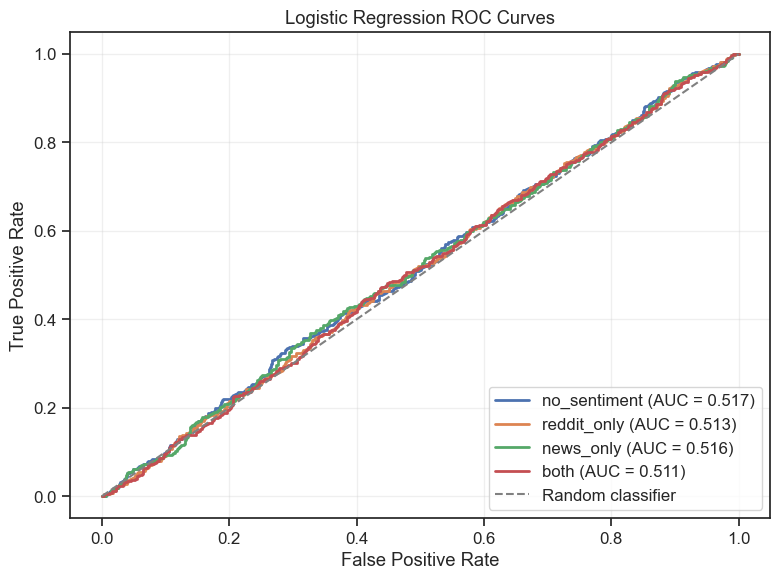

In [15]:
config_order = ['no_sentiment', 'reddit_only', 'news_only', 'both']

plt.figure(figsize=(8,6))

for config in config_order:

    model = lr_pipelines[config]

    y_prob = model.predict_proba(
        X_test[feature_configs[config]]
    )[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{config} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray',
    label='Random classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

*Logistic Regression achieved ROC-AUC values between 0.51 and 0.52 across all feature configurations. The results are only marginally above random guessing (ROC-AUC = 0.50), indicating that the relationship between the available predictors and next-day stock price direction is either weak, highly non-linear, or obscured by market noise. The inclusion of Reddit and news features produced only minor improvements in predictive performance.*

## 8. XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble method based on 
gradient-boosted decision trees. Unlike Logistic Regression, it captures 
non-linear relationships and feature interactions, making it particularly 
well-suited for financial time-series prediction where the relationship 
between predictors and the target is rarely linear.

*A separate pipeline is trained for each of the four ablation configurations, 
following the same structure as the Logistic Regression pipeline. 
Hyperparameter tuning is performed via GridSearchCV with TimeSeriesSplit.*

### 8.1 Hyperparameter tuning and predicition

In [16]:
param_grid_xgb = {
    'model__n_estimators':  [100, 300, 500],
    'model__max_depth':     [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample':     [0.7,0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5],
}

xgb_results     = {}
xgb_pipelines   = {}
xgb_best_params = {}

for config_name, feature_cols in feature_configs.items():
    print(f"\n{'─'*55}")
    print(f"  Configuration: {config_name}  ({len(feature_cols)} features)")
    print(f"{'─'*55}")

    pipeline = Pipeline([
        ('prep',  build_preprocessor(feature_cols, model_type='xgb')),
        ('model', XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            verbosity=0
        ))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_xgb,
        cv=tscv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train[feature_cols], y_train)

    best_pipeline = grid_search.best_estimator_
    best_params   = grid_search.best_params_

    y_pred      = best_pipeline.predict(X_test[feature_cols])
    y_pred_prob = best_pipeline.predict_proba(X_test[feature_cols])[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_pred_prob),
        'f1':        f1_score(y_test, y_pred),
        'f1_macro':  f1_score(y_test, y_pred, average='macro'),
    }

    xgb_results[config_name]     = metrics
    xgb_pipelines[config_name]   = best_pipeline
    xgb_best_params[config_name] = best_params

    print(f"  Best params : {best_params}")
    print(f"  Accuracy    : {metrics['accuracy']:.4f}")
    print(f"  ROC-AUC     : {metrics['roc_auc']:.4f}")
    print(f"  F1          : {metrics['f1']:.4f}")
    print(f"  F1 (macro)  : {metrics['f1_macro']:.4f}")


───────────────────────────────────────────────────────
  Configuration: no_sentiment  (25 features)
───────────────────────────────────────────────────────
  Best params : {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 100, 'model__subsample': 0.7}
  Accuracy    : 0.5108
  ROC-AUC     : 0.5222
  F1          : 0.5807
  F1 (macro)  : 0.4968

───────────────────────────────────────────────────────
  Configuration: reddit_only  (28 features)
───────────────────────────────────────────────────────
  Best params : {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__subsample': 0.7}
  Accuracy    : 0.5216
  ROC-AUC     : 0.5264
  F1          : 0.6032
  F1 (macro)  : 0.5004

───────────────────────────────────────────────────────
  Configuration: news_only  (27 features)
────────────────────────────────

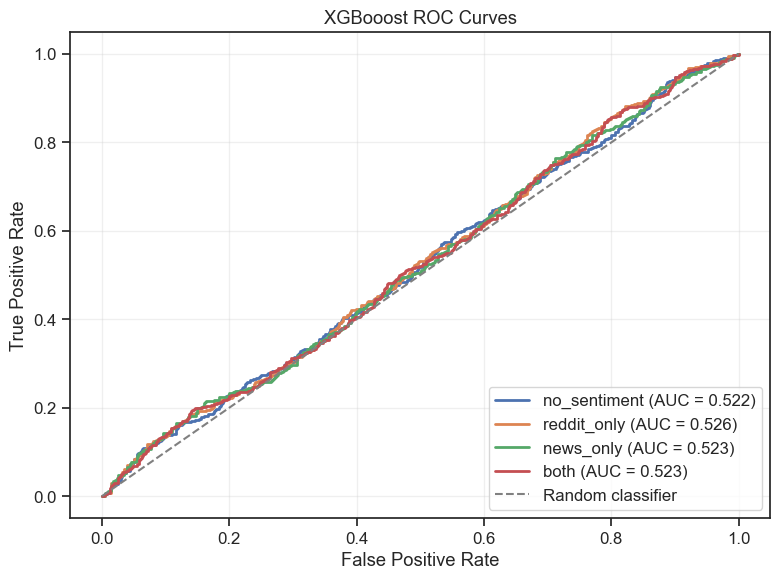

In [19]:
config_order = ['no_sentiment', 'reddit_only', 'news_only', 'both']

plt.figure(figsize=(8,6))

for config in config_order:

    model = xgb_pipelines[config]

    y_prob = model.predict_proba(
        X_test[feature_configs[config]]
    )[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{config} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray',
    label='Random classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBooost ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2. Results comparison across configurations

XGBoost achieved ROC-AUC values between 0.508 and 0.538 across all 
feature configurations marginally above random guessing (ROC-AUC = 0.50), 
consistent with the results obtained by Logistic Regression.


Notably, the optimal hyperparameters across all configurations converged 
toward shallow trees (`max_depth=3`) and strong regularization 
(`min_child_weight=3–5`, `subsample=0.7–0.8`), which is consistent with 
a low signal-to-noise ratio in the data. The model complexity was 
effectively constrained by the cross-validation procedure, indicating 
that the weak predictive performance is not attributable to underfitting 
but rather to the limited predictability of next-day price direction 
from the available features.

## 9. Conclusion

These results are consistent with the Efficient Market Hypothesis (EMH), 
which posits that asset prices already reflect all publicly available 
information, making systematic short-term prediction from public news 
and social media data inherently difficult. The findings align with 
prior literature (e.g., Tetlock, 2007; Barber & Odean, 2008) which 
documents that while sentiment and attention measures carry statistically 
detectable signals, their economic magnitude is typically small.